In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [2]:
dataset_path = "/Users/adnanaminmir/Desktop/MAIN_PROJECT/Garbage classification"

In [3]:
print("Dataset Exists:", os.path.exists(dataset_path))
print(os.listdir(dataset_path))

Dataset Exists: True
['paper', 'metal', 'cardboard', 'trash', 'glass', 'plastic']


In [4]:
import os

ds_file = "/Users/adnanaminmir/Desktop/MAIN_PROJECT/Garbage classification/.DS_Store"

if os.path.exists(ds_file):
    os.remove(ds_file)
    print(".DS_Store removed")
else:
    print("No .DS_Store found")

No .DS_Store found


In [5]:
print(os.listdir(dataset_path))

['paper', 'metal', 'cardboard', 'trash', 'glass', 'plastic']


In [6]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)


train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="training"
)


validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="validation"
)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


In [7]:
print(train_generator.class_indices)
print("Number of Classes:", train_generator.num_classes)

{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}
Number of Classes: 6


In [8]:
print(train_generator.class_indices)

print("Total Classes:", train_generator.num_classes)

{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}
Total Classes: 6


In [9]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)


base_model.trainable = False

In [10]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(
    128,
    activation="relu"
)(x)


x = Dropout(0.3)(x)


output = Dense(
    6,
    activation="softmax"
)(x)


model = Model(
    inputs=base_model.input,
    outputs=output
)

In [11]:
model.compile(
    optimizer=Adam(
        learning_rate=0.0001
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [12]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15
)

Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 44s 639ms/step - accuracy: 0.3844 - loss: 1.5923 - val_accuracy: 0.5328 - val_loss: 1.1998
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 39s 611ms/step - accuracy: 0.5855 - loss: 1.0888 - val_accuracy: 0.6103 - val_loss: 1.0017
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 39s 610ms/step - accuracy: 0.6630 - loss: 0.8988 - val_accuracy: 0.6600 - val_loss: 0.8995
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 40s 623ms/step - accuracy: 0.7001 - loss: 0.8039 - val_accuracy: 0.6740 - val_loss: 0.8480
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 40s 618ms/step - accuracy: 0.7297 - loss: 0.7176 - val_accuracy: 0.6640 - val_loss: 0.8070
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 43s 673ms/step - accuracy: 0.7564 - loss: 0.6752 - val_accuracy: 0.6859 - val_loss: 0.7714
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 40s 621ms/step - accuracy: 0.7767 - loss: 0.6275 - val_accuracy: 0.6899 - val_loss: 0.7628
Epoch 8/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 44s 693ms/step - accuracy: 0.7792 - loss: 0.5974 - val_accu

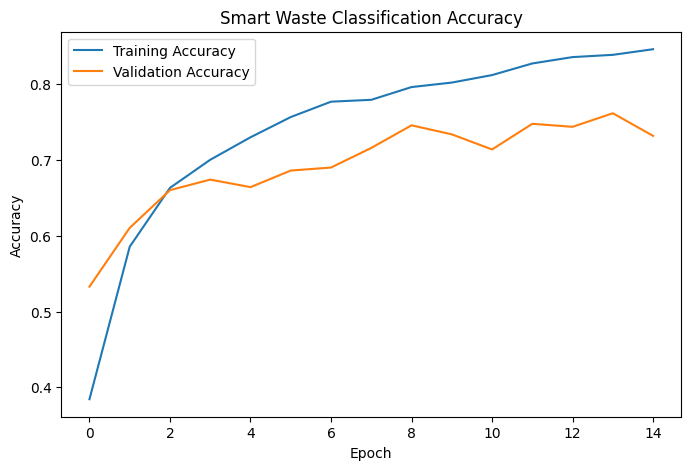

In [13]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label="Training Accuracy"
)

plt.plot(
    history.history['val_accuracy'],
    label="Validation Accuracy"
)


plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Smart Waste Classification Accuracy"
)

plt.legend()

plt.show()

In [14]:
model.save(
    "smart_waste_model.h5"
)


print(
    "Model Saved Successfully"
)

Model Saved Successfully


In [15]:
img_path = "/Users/adnanaminmir/Desktop/WhatsApp Image 2026-05-19 at 16.23.20.jpeg"


img = image.load_img(
    img_path,
    target_size=(224,224)
)


img_array = image.img_to_array(img)

img_array = np.expand_dims(
    img_array,
    axis=0
)

img_array = img_array / 255.0

In [16]:
prediction = model.predict(
    img_array
)


classes = [
    "cardboard",
    "glass",
    "metal",
    "paper",
    "plastic",
    "trash"
]


result = classes[
    np.argmax(prediction)
]


confidence = np.max(
    prediction
) * 100


print(
    "Predicted Waste Category:",
    result
)


print(
    "Confidence:",
    round(confidence,2),
    "%"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 723ms/step
Predicted Waste Category: glass
Confidence: 69.21 %


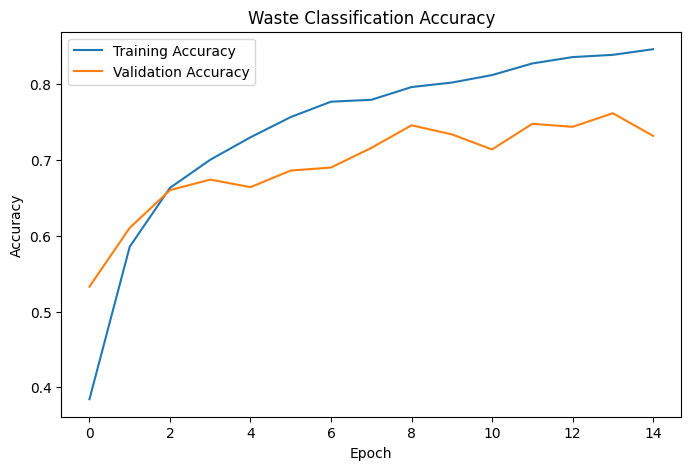

In [17]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Waste Classification Accuracy")

plt.legend()
plt.show()